Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [2]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [3]:
# Specify file paths
data_file = "sample-data/20251111-122213-cytation5-pure-timecourse-gfp-MFG-98-tRNA-QC-biotek-cdk.txt"
platemap_file = "sample-data/platemap.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Temperature,Well,Data,Row,Column,Read,Plate,Clock Time,Date,...,DNA ID,[DNA] (ng/uL),PMix Vol (uL),Ribosome Vol (uL),SMS Vol (uL),tRNA Vol (uL),DNA Vol (uL),RNase Inhib Vol (uL),Water vol (uL),Rxn Volume (uL)
0,0 days 00:00:33,25.10,B2,245,B,2,GFP-Gext,Plate 1,2025-11-11 12:24:37,11/11/2025,...,AR-805,120.00,3.00,NaN,3.00,1.00,0.50,0.50,2.00,10.00
1,0 days 00:05:33,31.70,B2,254,B,2,GFP-Gext,Plate 1,2025-11-11 12:29:37,11/11/2025,...,AR-805,120.00,3.00,NaN,3.00,1.00,0.50,0.50,2.00,10.00
2,0 days 00:10:33,36.50,B2,249,B,2,GFP-Gext,Plate 1,2025-11-11 12:34:37,11/11/2025,...,AR-805,120.00,3.00,NaN,3.00,1.00,0.50,0.50,2.00,10.00
3,0 days 00:15:33,36.90,B2,230,B,2,GFP-Gext,Plate 1,2025-11-11 12:39:37,11/11/2025,...,AR-805,120.00,3.00,NaN,3.00,1.00,0.50,0.50,2.00,10.00
4,0 days 00:20:33,37.00,B2,265,B,2,GFP-Gext,Plate 1,2025-11-11 12:44:37,11/11/2025,...,AR-805,120.00,3.00,NaN,3.00,1.00,0.50,0.50,2.00,10.00


## Plot Raw Curves

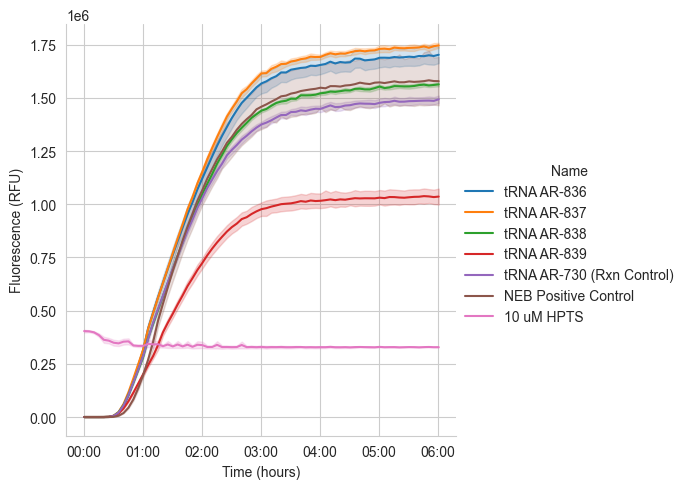

In [4]:
g = pr.plot_curves(data=data)

## Normalize Data

In [5]:
data = pr.normalize_data_to_controls(data, ctrl_name = '10 uM HPTS')

Data Normalized to 10 uM HPTS in col data_normalized. The active column for subsequent operations is: data_normalized


Now replot your curves to see them normalized

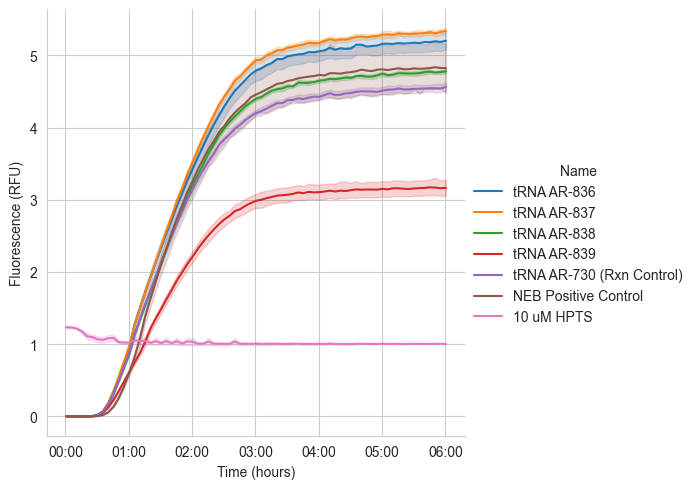

In [6]:
g = pr.plot_curves(data=data)

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [10]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Well','Name'],  # Group by experimental condition
)

kinetics.head()

Calculating Kinetics


Velocity                       \
                                               Time data_normalized  Max   
Well Name                                                                  
B2   tRNA AR-836          0 days 01:33:15.324363352            2.51 2.50   
B4   tRNA AR-837          0 days 01:33:35.489983885            2.64 2.68   
B6   tRNA AR-838          0 days 01:32:34.620347072            2.38 2.45   
B8   tRNA AR-839          0 days 01:31:59.972075562            1.53 1.68   
B12  NEB Positive Control 0 days 01:35:49.671310037            2.26 2.68   

                                                Lag                  \
                                               Time data_normalized   
Well Name                                                             
B2   tRNA AR-836          0 days 00:33:09.163367928            0.21   
B4   tRNA AR-837          0 days 00:34:37.607553264            0.25   
B6   tRNA AR-838          0 days 00:34:21.489999592            0.22   
B8   tRNA AR-839          0 days 00:37:34.773966771            0.18   
B12  NEB Positive Control 0 days 00:45:09.296518471            0.31   

                                       Steady State                  \
                                               Time data_normalized   
Well Name                                                             
B2   tRNA AR-836          0 days 03:01:44.384862874            4.76   
B4   tRNA AR-837          0 days 03:00:24.029448796            5.01   
B6   tRNA AR-838          0 days 02:58:17.274924181            4.52   
B8   tRNA AR-839          0 days 02:52:07.060367848            2.90   
B12  NEB Positive Control 0 days 02:50:25.770333764            4.29   

                                                                         Fit  \
                                                                      params   
Well Name                                                                      
B2   tRNA AR-836           [5.015409575928889, 1.9965830726466682, 1.5542...   
B4   tRNA AR-837           [5.273769484686327, 2.0351156780907864, 1.5598...   
B6   tRNA AR-838           [4.7623070188270065, 2.061188471063635, 1.5429...   
B8   tRNA AR-839           [3.0546934271614314, 2.2050729423897244, 1.533...   
B12  NEB Positive Control  [4.5184298177171, 2.3681290938415547, 1.597130...   

                                               
                           R^2 drift good_fit  
Well Name                                      
B2   tRNA AR-836          1.00  0.07     True  
B4   tRNA AR-837          1.00  0.07     True  
B6   tRNA AR-838          1.00  0.06     True  
B8   tRNA AR-839          1.00  0.03     True  
B12  NEB Positive Control 1.00  0.09     True

## Visualize Fits on Individual Wells

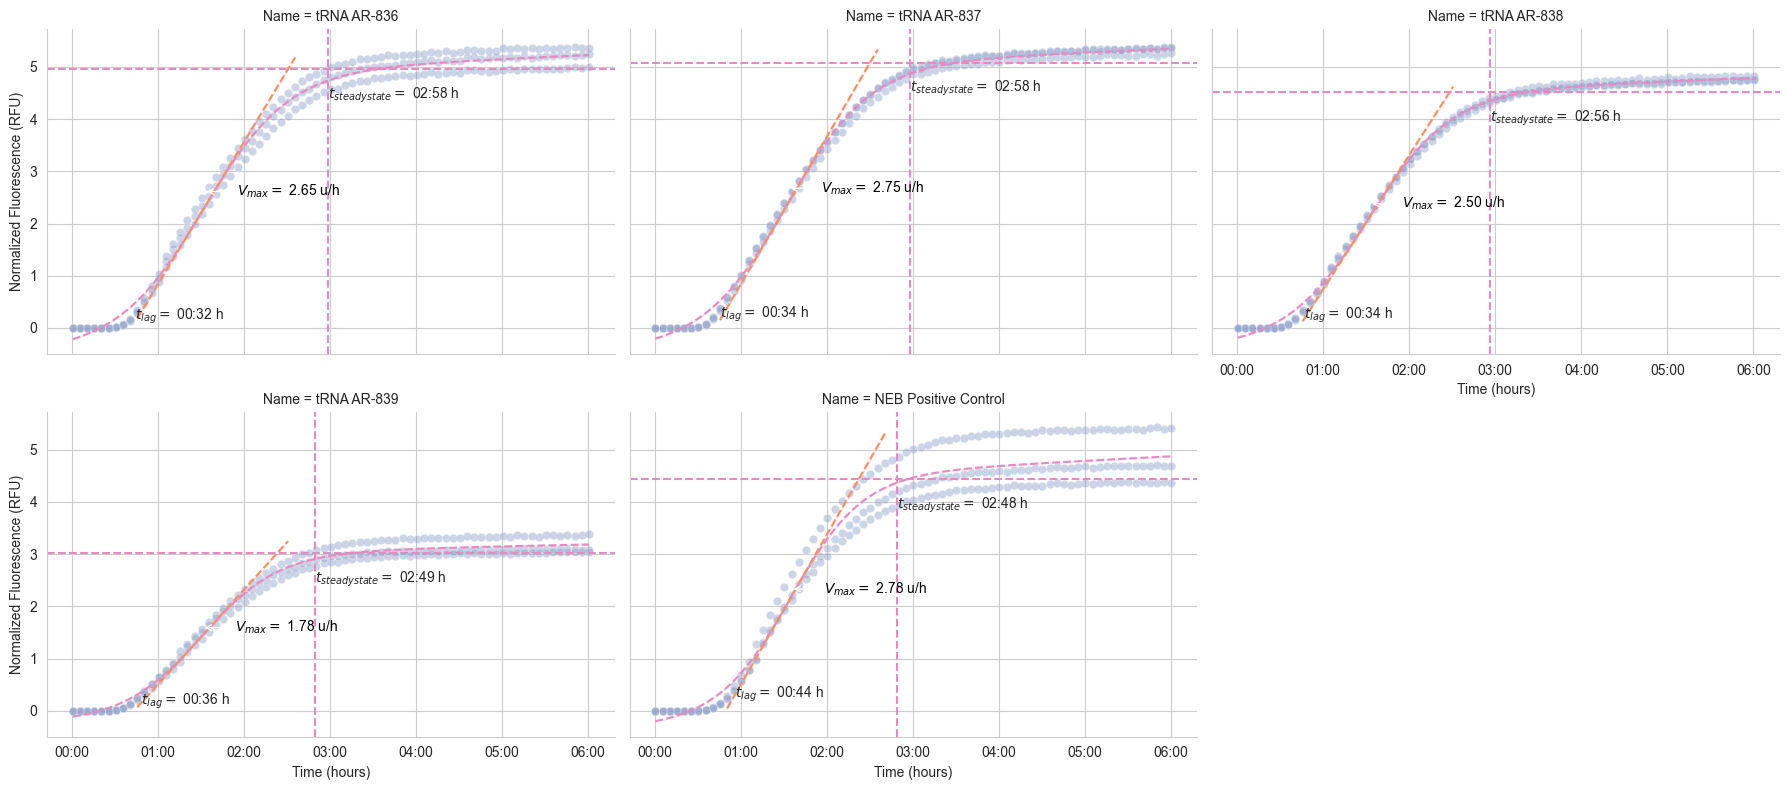

In [14]:
# Plot kinetic fits 
g = pr.plot_kinetics(data, kinetics=kinetics)

## Summary Plots

Calculating Kinetics


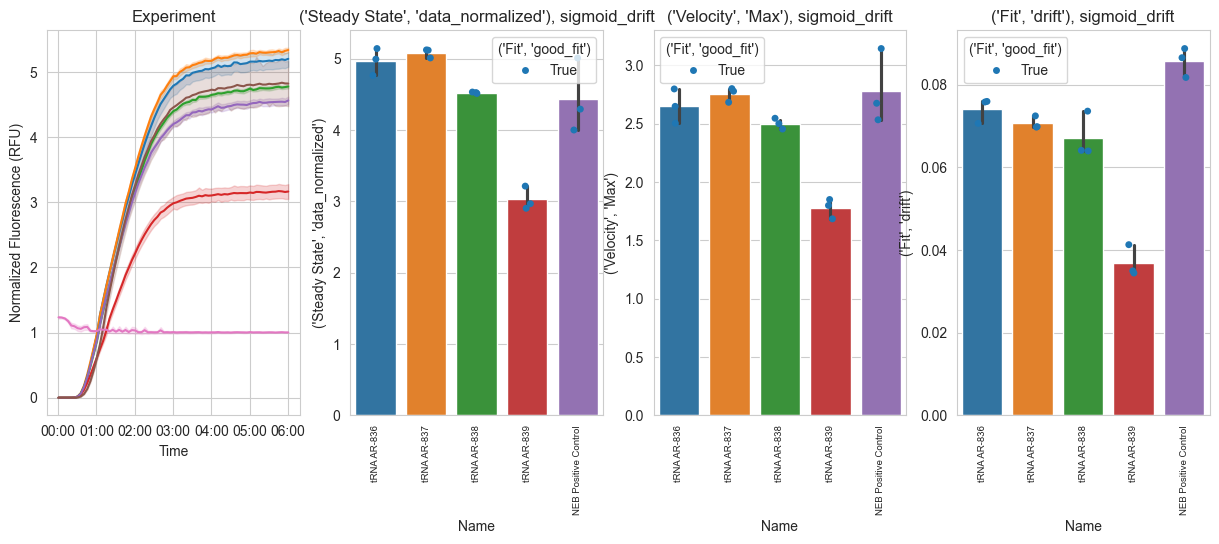

In [13]:
g = pr.plot_summary(data)
# g.savefig("summary.png", dpi=300)

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants